In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

recipe_df = pd.read_csv("csv/full_dataset.csv", index_col=0)
recipe_df.head(1)

,title,ingredients,directions,link,source,NER
0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."


In [2]:
num_ings = [len(eval(row.loc['NER'])) for i, row in recipe_df.iterrows()]
num_steps = [len(eval(row.loc['directions'])) for i, row in recipe_df.iterrows()]

(array([4.929950e+05, 1.181653e+06, 4.400090e+05, 9.057700e+04,
        1.895500e+04, 4.499000e+03, 1.197000e+03, 3.900000e+02,
        1.710000e+02, 6.500000e+01, 2.900000e+01, 6.000000e+00,
        7.000000e+00, 4.000000e+00, 3.000000e+00, 0.000000e+00,
        2.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 1.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 1.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.00

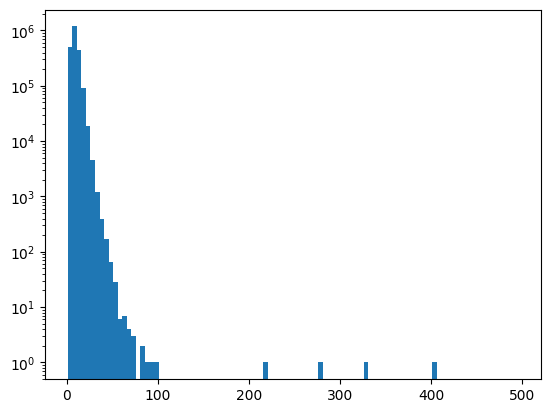

In [3]:
bins=range(1,500,5)
counts, bins = np.histogram(num_ings, bins=bins)
plt.hist(bins[:-1], bins, log=True, weights=counts)

(array([1.489224e+06, 7.079010e+05, 3.169000e+04, 1.978000e+03,
        2.700000e+02, 5.300000e+01, 1.100000e+01, 6.000000e+00,
        3.000000e+00, 2.000000e+00]),
 array([ 0. ,  9.8, 19.6, 29.4, 39.2, 49. , 58.8, 68.6, 78.4, 88.2, 98. ]),
 <BarContainer object of 10 artists>)

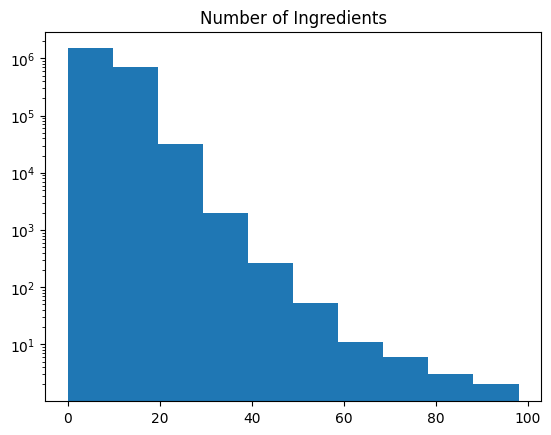

In [4]:
truncated_num_ings = [ings for ings in num_ings if ings < 200]
bins=range(1,100,5)
counts, bins = np.histogram(truncated_num_ings)
plt.title('Number of Ingredients')
plt.hist(bins[:-1], bins, log=True, weights=counts)

(array([1.158996e+06, 7.253680e+05, 2.158080e+05, 7.476000e+04,
        3.020700e+04, 1.333800e+04, 6.173000e+03, 2.933000e+03,
        1.538000e+03, 7.790000e+02, 4.770000e+02, 2.760000e+02,
        1.620000e+02, 9.700000e+01, 7.100000e+01, 2.600000e+01,
        2.400000e+01, 3.000000e+01, 1.900000e+01, 1.600000e+01,
        6.000000e+00, 1.000000e+01, 7.000000e+00, 2.000000e+00,
        2.000000e+00, 3.000000e+00, 3.000000e+00, 2.000000e+00,
        5.000000e+00, 1.000000e+00, 1.000000e+00, 0.000000e+00,
        2.000000e+00]),
 array([  1.,   6.,  11.,  16.,  21.,  26.,  31.,  36.,  41.,  46.,  51.,
         56.,  61.,  66.,  71.,  76.,  81.,  86.,  91.,  96., 101., 106.,
        111., 116., 121., 126., 131., 136., 141., 146., 151., 156., 161.,
        166.]),
 <BarContainer object of 33 artists>)

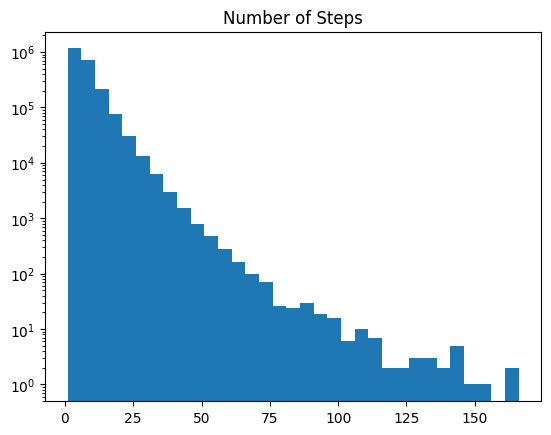

In [5]:
bins=range(1,170,5)
counts, bins = np.histogram(num_steps, bins=bins)
plt.title('Number of Steps')
plt.hist(bins[:-1], bins, log=True, weights=counts)

In [3]:
recipe_df['num_ings'] = num_ings
recipe_df['num_steps'] = num_steps

In [4]:
partial = recipe_df.loc[recipe_df['num_steps']<100].loc[recipe_df['num_steps']>=75]

with open("instruction_file.txt", "w") as f:
    for row in partial['directions']:
        directions = eval(row)
        for step in directions:
            f.write(step)
            f.write("\n")
        f.write("=" * 50)
        f.write("\n")


In [5]:
partial

,title,ingredients,directions,link,source,NER,num_ings,num_steps
973309,Birch De Noel - Yule Log,"[""Chocolate Cake"", ""1 fresh coconut"", ""6 large...","[""Chocolate Cake:"", ""Heat oven to 350\u00b0F"",...",www.food.com/recipe/birch-de-noel-yule-log-220282,Gathered,"[""Chocolate Cake"", ""fresh coconut"", ""eggs"", ""s...",24,76
1278920,"The Four Dances: Soused Snook, Octopus With Aï...","[""See Preparation""]","[""2 medium size fillet of snook OR 10 oz (very...",www.epicurious.com/recipes/food/views/the-four...,Gathered,"[""Preparation""]",1,89
1644774,Caesar Chicken Pizza,"[""Whole Wheat Pizza Dough, recipe follows"", ""2...","[""Place a pizza stone on the middle rack of th...",www.foodnetwork.com/recipes/caesar-chicken-piz...,Recipes1M,"[""Dough"", ""chili oil"", ""Tomatoes"", ""mozzarella...",13,79
1647660,Vanilla Petits Fours with Raspberry Filling an...,"[""1/2 cup (1 stick) unsalted butter, plus more...","[""Preheat oven to 350F."", ""Butter pan and line...",www.epicurious.com/recipes/food/views/vanilla-...,Recipes1M,"[""unsalted butter"", ""eggs"", ""sugar"", ""cake flo...",16,88
1649535,Harlequin Soup,"[""1 recipe Very Green Broccoli Soup"", ""1 recip...","[""Ladle some of each soup into its own pitcher...",www.foodnetwork.com/recipes/michael-chiarello/...,Recipes1M,"[""recipe Very Green Broccoli Soup"", ""Soup"", ""F...",15,99
...,...,...,...,...,...,...,...,...
2195516,The Best Biscuits Ever,"[""2 tablespoons (1 oz / 28.5 g) white vinegar,...","[""Stir the vinegar into the cream to acidify i...",www.epicurious.com/recipes/food/views/the-best...,Recipes1M,"[""white vinegar"", ""cream"", ""cold unsalted butt...",9,91
2198742,Stollen,"[""1/2 cup (4 ounces) whole milk"", ""1/2 cup (2....","[""Make the sponge by warming the milk to about...",www.epicurious.com/recipes/food/views/stollen-...,Recipes1M,"[""milk"", ""flour"", ""yeast"", ""golden raisins"", ""...",19,85
2199015,Gingerbread Cookies and Citrus Sugar Cookies,"[""2 3/4 cups unbleached all purpose flour"", ""1...","[""Sift flour, ginger, baking soda, cinnamon an...",www.epicurious.com/recipes/food/views/gingerbr...,Recipes1M,"[""flour"", ""ground ginger"", ""baking soda"", ""gro...",17,85
2212535,Sourdough Bread: 100% Sourdough Rye Bread,"[""1/2 cup (3.5 ounces) barm (page 230) or rye ...","[""The day before making the dough, make the ry...",www.epicurious.com/recipes/food/views/sourdoug...,Recipes1M,"[""white rye flour"", ""water"", ""flour"", ""water"",...",8,84


In [7]:
partial = recipe_df.loc[recipe_df['num_ings']>40].loc[recipe_df['num_steps']>10]
clean = [row for i, row in partial.iterrows()
         if ':' not in row.loc['ingredients'] and 'For' not in row.loc['ingredients']]
# len(clean)
cleaned = pd.DataFrame.from_records(clean)
cleaned

,title,ingredients,directions,link,source,NER,num_ings,num_steps
0,Spinach Salad Dressing,"[""1 egg, slightly beaten"", ""2 tsp. Parmesan ch...","[""In a small bowl, combine soy sauce, Worceste...",www.cookbooks.com/Recipe-Details.aspx?id=872695,Gathered,"[""egg"", ""Parmesan cheese"", ""mustard"", ""lemon"",...",45,14
1,Hyderabadi Biryani (Yogurt Marinated Lamb),"[""The Lamb"", ""1 lb lamb, cut into 1-inch cubes...","[""Place lamb in a bowl, coat with yogurt, cove...",www.food.com/recipe/hyderabadi-biryani-yogurt-...,Gathered,"[""lamb"", ""yogurt"", ""ghee"", ""cloves"", ""pods"", ""...",41,12
2,Nicker'S Pulled Chicken Burritos,"[""Pulled Chicken"", ""4 chicken breasts"", ""2 gar...","[""Put beans in a bowl and cover with 5 cups of...",www.food.com/recipe/nickers-pulled-chicken-bur...,Gathered,"[""Chicken"", ""chicken breasts"", ""garlic"", ""sals...",49,11
3,Land And Sea White Meat Version Of Surf And Turf,"[""Salsa"", ""1 cup dice apricot"", ""1 cup diced n...","[""For Salsa-."", ""Mix all ingredients and chill...",www.food.com/recipe/land-and-sea-white-meat-ve...,Gathered,"[""Salsa"", ""apricot"", ""nectarine"", ""red pepper""...",46,46
4,Hocus Pocus Cottage Cake,"[""Chocolate Cake"", ""2 cups sugar"", ""1 cup milk...","[""Chocolate Cake:"", ""**note: this chocolate ca...",www.food.com/recipe/hocus-pocus-cottage-cake-5...,Gathered,"[""Chocolate Cake"", ""sugar"", ""milk"", ""vegetable...",41,38
...,...,...,...,...,...,...,...,...
163,Three Virtue Soup: Le Virtu,"[""1/4 pound pork rind"", ""1 pig trotter"", ""1 ha...","[""In a large pot, combine the pork rind, trott...",www.foodnetwork.com/recipes/mario-batali/three...,Recipes1M,"[""pork rind"", ""trotter"", ""ham bone"", ""beef sha...",41,45
164,Beet Salad With Chevre Frais and Caraway,"[""1 1/2 to 2 pounds large red beets"", ""1 1/2 t...","[""Preheat oven to 400 degrees."", ""Wash the bee...",cooking.nytimes.com/recipes/1015408,Recipes1M,"[""red beets"", ""beets"", ""golden beets"", ""olive ...",41,11
165,Hyderabadi Lamb Biryani,"[""10 black peppercorns"", ""2 whole cloves"", ""On...","[""Make the garam masala In a small skillet, to...",www.foodandwine.com/recipes/hyderabadi-lamb-bi...,Recipes1M,"[""black"", ""cloves"", ""cinnamon"", ""caraway seeds...",53,34
166,Beautiful Leftover Roasted Veg Bruschetta,"[""Gennaro's Bruschetta"", ""1 slice sourdough br...","[""The word 'bruschetta' comes from the Italian...",www.foodnetwork.com/recipes/beautiful-leftover...,Recipes1M,"[""Gennaro's Bruschetta"", ""bread"", ""leftover ro...",43,40


In [8]:
partial = recipe_df.loc[recipe_df['num_ings']==12].loc[recipe_df['num_steps']>20]
partial

,title,ingredients,directions,link,source,NER,num_ings,num_steps
590,Bouillabaisse,"[""1 c. minced onions"", ""1/2 c. minced leeks"", ...","[""Cook onions and"", ""leeks\tslowly in the oil ...",www.cookbooks.com/Recipe-Details.aspx?id=244918,Gathered,"[""onions"", ""leeks"", ""olive oil"", ""garlic"", ""to...",12,35
3296,Beef And Bean Enchiladas,"[""3/4 lb. lean ground beef"", ""2 cloves garlic""...","[""Brown"", ""ground beef with"", ""minced"", ""garli...",www.cookbooks.com/Recipe-Details.aspx?id=713675,Gathered,"[""lean ground beef"", ""garlic"", ""picante sauce""...",12,33
4808,Pumpkin Chiffon Cake,"[""2 c. flour, sifted"", ""1 1/2 c. sugar"", ""3 ts...","[""Sift dry ingredients"", ""into bowl."", ""Separa...",www.cookbooks.com/Recipe-Details.aspx?id=633641,Gathered,"[""flour"", ""sugar"", ""baking powder"", ""salt"", ""c...",12,23
6263,Orange Slice Cake,"[""1 c. butter or margarine"", ""2 c. sugar"", ""4 ...","[""Preheat oven"", ""to"", ""250\u00b0."", ""In"", ""la...",www.cookbooks.com/Recipe-Details.aspx?id=548209,Gathered,"[""butter"", ""sugar"", ""eggs"", ""baking soda"", ""bu...",12,27
9153,Swiss Steak,"[""round steak, tenderized"", ""flour"", ""salt and...","[""Salt"", ""and"", ""pepper"", ""steak"", ""to"", ""tast...",www.cookbooks.com/Recipe-Details.aspx?id=713721,Gathered,"[""flour"", ""salt"", ""bell pepper"", ""onion"", ""tom...",12,23
...,...,...,...,...,...,...,...,...
2230817,Stuffed and Grilled Corn Husks,"[""4 large fresh ears corn"", ""3 tablespoons fre...","[""Carefully remove the husks of each ear of co...",www.foodnetwork.com/recipes/stuffed-and-grille...,Recipes1M,"[""fresh ears corn"", ""lime juice"", ""garlic"", ""g...",12,21
2230830,Lobster Macaroni and Cheese,"[""4 whole 1 1/4 Pound Size Lobsters"", ""1 bottl...","[""1."", ""Pour a bottle of beer into a large lob...",tastykitchen.com/recipes/main-courses/lobster-...,Recipes1M,"[""Lobsters"", ""Butter"", ""White Flour"", ""Milk"", ...",12,51
2230889,Chocolate Mint Chip Parfait,"[""1 bunch fresh mint"", ""2 large egg whites"", ""...","[""Remove the large leaves from the mint (about...",www.epicurious.com/recipes/food/views/chocolat...,Recipes1M,"[""mint"", ""egg whites"", ""sugar"", ""bittersweet c...",12,50
2230989,Szechuan Beef Recipe,"[""1 pound beef top round steak"", ""5 carrots, r...","[""Partially freeze beef."", ""Cut on the bias in...",cookeatshare.com/recipes/szechuan-beef-23467,Recipes1M,"[""steak"", ""carrots"", ""sherry"", ""soy sauce"", ""w...",12,26


In [9]:
from generate_test_csv import generate_from_df

single = cleaned.loc[cleaned['title']=='Shrimp Cakes With Roasted Shrimp Sauce']
generate_from_df(single)

1. reading recipe Shrimp Cakes With Roasted Shrimp Sauce:
generating ingredient list...
generating direction list...



/Users/jerryliu/Desktop/workspace/cookingLlama/generate_test_csv.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_outputs['formatted_ingredients'] = formatted_ingredients
/Users/jerryliu/Desktop/workspace/cookingLlama/generate_test_csv.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_outputs['formatted_ingredient_list'] = formatted_ingredient_list
/Users/jerryliu/Desktop/workspace/cookingLlama/generate_test_csv.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of

,title,ingredients,directions,formatted_ingredients,formatted_ingredient_list,formatted_directions
8,Shrimp Cakes With Roasted Shrimp Sauce,"[""SHRIMP CAKES"", ""1 lb large shrimp, peeled, d...","[""SHRIMP CAKES:."", ""Toss the shrimp with 1 tab...","shrimp = Ingredient('shrp', 'large shrimp, pee...","ingredients = [shrimp, seasoning, seasoning2, ...","t2 = Transformation('mix', 'Toss the shrimp wi..."


In [13]:
ings = "shrimp = Ingredient('shrp', 'large shrimp, peeled, deveined, cut into 1/2-inch pieces', 454, over='too fishy', under='too sparse')\nseasoning = Ingredient('seas', 'Emeril\'s Original Essence or creole seasoning', 24, over='too salty', under='too bland')\nseasoning2 = Ingredient('sea2', 'Emeril\'s Original Essence or creole seasoning', 3, over='too salty', under='too bland')\nvegoil = Ingredient('vego', 'vegetable oil', 68, over='too greasy', under='too dry')\nonion = Ingredient('onio', 'chopped yellow onion', 80, over='too oniony', under='too flat')\ncelery = Ingredient('cel1', 'chopped celery', 25, over='too vegetal', under='too plain')\nbellpepper = Ingredient('bell', 'chopped green bell peppers or red bell pepper', 38, over='too peppery', under='too plain')\ngarlic = Ingredient('gar1', 'minced garlic', 3, over='too garlicky', under='too dull')\ncayenne = Ingredient('cay1', 'cayenne pepper or crushed red pepper flakes', 1, over='too spicy', under='too mild')\neggwhite = Ingredient('egwh', 'large egg white, very cold', 33, over='too rubbery', under='too crumbly')\ncream = Ingredient('crm1', 'cold heavy cream, very cold', 60, over='too rich', under='too lean')\ngreenonion = Ingredient('gron', 'green onion, chopped, green tops only', 50, over='too oniony', under='too bland')\ndijon = Ingredient('dijn', 'Dijon mustard', 15, over='too sharp', under='too mild')\nlemonjuice = Ingredient('lmnj', 'fresh lemon juice', 10, over='too sour', under='too dull')\nworcestershire = Ingredient('worc', 'Worcestershire sauce', 5, over='too pungent', under='too bland')\nhotsauce = Ingredient('hots', 'emeril\'s kick it up red pepper sauce', 5, over='too spicy', under='too tame')\nbasil = Ingredient('basi', 'finely chopped fresh basil leaf', 1, over='too herbal', under='too dull')\nparsley = Ingredient('pars', 'finely chopped fresh parsley leaves', 1, over='too herbal', under='too dull')\nflour = Ingredient('flou', 'all-purpose flour', 120, over='too floury', under='too sticky')\neggs = Ingredient('eggs', 'large eggs', 100, over='too eggy', under='too crumbly')\nbreadcrumbs = Ingredient('brcr', 'dried fine breadcrumbs', 100, over='too bready', under='too loose')\nparsley_garnish = Ingredient('pgar', 'chopped fresh parsley leaves, for garnish', 15, over='too grassy', under='too bare')\noliveoil = Ingredient('oliv', 'olive oil', 27, over='too oily', under='too dry')\nshells = Ingredient('shll', 'shrimp shells and heads', 200, over='too shrimpy', under='too weak')\nonion_sauce = Ingredient('oni2', 'chopped yellow onion', 80, over='too oniony', under='too flat')\ncarrot = Ingredient('carr', 'chopped carrot', 32, over='too sweet', under='too thin')\ncelery2 = Ingredient('cel2', 'chopped celery', 25, over='too vegetal', under='too plain')\ngarlic2 = Ingredient('gar2', 'chopped garlic', 3, over='too garlicky', under='too dull')\npaprika = Ingredient('papr', 'paprika', 4, over='too smoky', under='too pale')\ncayenne2 = Ingredient('cay2', 'cayenne', 1, over='too spicy', under='too mild')\nsalt = Ingredient('salt', 'salt', 2, over='too salty', under='too bland')\nsalt2 = Ingredient('sal2', 'salt', 1, over='too salty', under='too bland')\ntomatopaste = Ingredient('tmpa', 'tomato paste', 5, over='too tomatoey', under='too weak')\nbrandy = Ingredient('brnd', 'brandy', 29, over='too boozy', under='too flat')\nwater = Ingredient('watr', 'water', 120, over='too watery', under='too thick')\ncream2 = Ingredient('crm2', 'heavy cream', 720, over='too rich', under='too thin')\nbutter = Ingredient('butr', 'cold butter, cut into pieces', 57, over='too buttery', under='too lean')\nlemonjuice2 = Ingredient('lmj2', 'fresh lemon juice', 1, over='too sour', under='too flat')\n"
len(ings.split('\n'))

39

In [17]:
print("ingredients = [shrimp, seasoning, seasoning2, vegoil, onion, celery, bellpepper, garlic, cayenne, eggwhite, cream, greenonion, dijon, lemonjuice, worcestershire, hotsauce, basil, parsley, flour, eggs, breadcrumbs, parsley_garnish, oliveoil, shells, onion_sauce, carrot, celery2, garlic2, paprika, cayenne2, salt, salt2, tomatopaste, brandy, water, cream2, butter, lemonjuice2]")

ingredients = [shrimp, seasoning, seasoning2, vegoil, onion, celery, bellpepper, garlic, cayenne, eggwhite, cream, greenonion, dijon, lemonjuice, worcestershire, hotsauce, basil, parsley, flour, eggs, breadcrumbs, parsley_garnish, oliveoil, shells, onion_sauce, carrot, celery2, garlic2, paprika, cayenne2, salt, salt2, tomatopaste, brandy, water, cream2, butter, lemonjuice2]


In [16]:
print("t2 = Transformation('mix', 'Toss the shrimp with 1 tablespoon of the Essence.', [shrimp, seasoning], 'seasoned_shrimp')\nt3 = Transformation('chill', 'Place half of the shrimp in the refrigerator until well chilled, about 20 minutes.', [t2.execute()], 'chilled_shrimp')\nt5 = Transformation('fry', 'Heat the oil in a large skillet over medium-high heat.', [vegoil], 'heated_oil')\nt6 = Transformation('fry', 'Add the onions, celery, bell peppers, garlic, cayenne pepper and 1 teaspoon Essence and cook, stirring, for 3 minutes.', [t5.execute(), onion, celery, bellpepper, garlic, cayenne, seasoning], 'cooked_veg')\nt7 = Transformation('fry', 'Add the remaining half of the shrimp and cook until pink, 3 to 3 1/2 minutes.', [t6.execute(), t2.execute()], 'shrimp_veg_mix')\nt8 = Transformation('chill', 'Remove from the heat and spread on a plate to cool completely.', [t7.execute()], 'cooled_shrimp_veg_mix')\nt9 = Transformation('mix', 'Place the chilled shrimp in the bowl of the food processor and process for 10 seconds.', [t3.execute()], 'processed_chilled_shrimp')\nt10 = Transformation('mix', 'Add the egg white and process for 5 seconds.', [t9.execute(), eggwhite], 'shrimp_paste')\nt11 = Transformation('mix', 'With the machine running, add the heavy cream through the feed tube in a steady stream.', [t10.execute(), cream], 'shrimp_mousse')\nt13 = Transformation('mix', 'Add the cooked shrimp mixture, green onions, mustard, lemon juice, Worcestershire sauce, red pepper sauce, basil, and parsley, and mix well.', [t11.execute(), t8.execute(), greenonion, dijon, lemonjuice, worcestershire, hotsauce, basil, parsley], 'shrimp_cake_mix')\nt15 = Transformation('mix', 'In a shallow bowl combine the flour with 1 tablespoon of the Essence.', [flour, seasoning], 'seasoned_flour')\nt16 = Transformation('mix', 'In a third bowl, combine the breadcrumbs with the remaining tablespoon of Essence.', [breadcrumbs, seasoning], 'seasoned_breadcrumbs')\nt17 = Transformation('mix', 'One at a time, dredge the shrimp cakes first in the seasoned flour, then egg and then bread crumbs, shaking to remove any excess breading.', [t13.execute(), t15.execute(), eggs, water, t16.execute()], 'breaded_shrimp_cakes')\nt18 = Transformation('fry', 'Heat 2 tablespoons of the oil in a large skillet over medium-high heat.', [vegoil], 'heated_oil_2')\nt19 = Transformation('fry', 'Add the cakes in batches and cook until golden brown, about 2 1/2 minutes per side.', [t18.execute(), t17.execute()], 'fried_shrimp_cakes')\nt22 = Transformation('fry', 'Heat the oil in a large, heavy pot to smoking over high heat.', [oliveoil], 'smoking_oil')\nt23 = Transformation('fry', 'Add shells and cook, stirring, until the shells are bright orange and fragrant, 3 minutes.', [t22.execute(), shells], 'roasted_shells')\nt24 = Transformation('fry', 'Add the onions, carrots, and celery to the pot and cook, stirring, for 3 minutes.', [t23.execute(), onion_sauce, carrot, celery2], 'shells_with_veggies')\nt25 = Transformation('fry', 'Add the garlic, paprika, cayenne, salt, and tomato paste and cook, stirring, until the tomato paste begins to brown slightly, 2 to 3 minutes.', [t24.execute(), garlic2, paprika, cayenne2, salt, tomatopaste], 'tomato_shell_base')\nt26 = Transformation('boil', 'Add the brandy and cook for about 15 seconds.', [t25.execute(), brandy], 'deglazed_base')\nt27 = Transformation('boil', 'Add the water and cook until the pan is almost dry, 15 to 30 seconds.', [t26.execute(), water], 'reduced_base')\nt28 = Transformation('boil', 'Add the cream and cook until reduced by half, about 7 minutes.', [t27.execute(), cream2], 'reduced_cream_base')\nt30 = Transformation('mix', 'With a hand-held immersion blender or in batches in a food processor, puree the sauce until smooth, about 1 minute.', [t28.execute()], 'pureed_shrimp_sauce')\nt32 = Transformation('stir', 'Place over medium heat and whisk in the cold butter 1 piece at a time.', [t30.execute(), butter], 'mounted_shrimp_sauce')")

t2 = Transformation('mix', 'Toss the shrimp with 1 tablespoon of the Essence.', [shrimp, seasoning], 'seasoned_shrimp')
t3 = Transformation('chill', 'Place half of the shrimp in the refrigerator until well chilled, about 20 minutes.', [t2.execute()], 'chilled_shrimp')
t5 = Transformation('fry', 'Heat the oil in a large skillet over medium-high heat.', [vegoil], 'heated_oil')
t6 = Transformation('fry', 'Add the onions, celery, bell peppers, garlic, cayenne pepper and 1 teaspoon Essence and cook, stirring, for 3 minutes.', [t5.execute(), onion, celery, bellpepper, garlic, cayenne, seasoning], 'cooked_veg')
t7 = Transformation('fry', 'Add the remaining half of the shrimp and cook until pink, 3 to 3 1/2 minutes.', [t6.execute(), t2.execute()], 'shrimp_veg_mix')
t8 = Transformation('chill', 'Remove from the heat and spread on a plate to cool completely.', [t7.execute()], 'cooled_shrimp_veg_mix')
t9 = Transformation('mix', 'Place the chilled shrimp in the bowl of the food processor and proce

In [19]:
head = cleaned.head(10)
formatted = generate_from_df(head)

1. reading recipe Spinach Salad Dressing:
generating ingredient list...
generating direction list...

2. reading recipe Hyderabadi Biryani (Yogurt Marinated Lamb):
generating ingredient list...
generating direction list...

3. reading recipe Nicker'S Pulled Chicken Burritos:
generating ingredient list...
generating direction list...

4. reading recipe Land And Sea White Meat Version Of Surf And Turf:
generating ingredient list...
generating direction list...

5. reading recipe Hocus Pocus Cottage Cake:
generating ingredient list...
generating direction list...

6. reading recipe Death By Chocolate A La Trellis:
generating ingredient list...
generating direction list...

7. reading recipe Peppermint Red Velvet Whoopie Pie:
generating ingredient list...
generating direction list...

8. reading recipe Parrillada Argentina With Red And Green Chimichurri Sauces:
generating ingredient list...
generating direction list...

9. reading recipe Shrimp Cakes With Roasted Shrimp Sauce:
generating i

/Users/jerryliu/Desktop/workspace/cookingLlama/generate_test_csv.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_outputs['formatted_ingredients'] = formatted_ingredients
/Users/jerryliu/Desktop/workspace/cookingLlama/generate_test_csv.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_outputs['formatted_ingredient_list'] = formatted_ingredient_list
/Users/jerryliu/Desktop/workspace/cookingLlama/generate_test_csv.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of

In [20]:
formatted.to_csv('csv/over40ing.csv', index=False, header=False)